# Fly Ash SCM Analysis

Analysis of fly ash usage patterns in concrete Environmental Product Declarations (EPDs) from the EC3 database, and geographic relationships between concrete plants using fly ash and coal plants that produce fly ash as a byproduct.

## Setup

Load required packages and the processed fly ash EPD data and coal plant datasets.

In [109]:
# Load packages
library(tidyverse)
library(scales)      # For nice axis formatting
library(ggthemes)    # Optional: additional themes

# Load your capstone data
fly_ash_data <- read_csv("../02_processed_data/epd_data_fly_ash.csv")
coal_plant_data <- read_csv("../02_processed_data/active_coal_plants_US.csv")

# Preview your data
#glimpse(fly_ash_data)
glimpse(coal_plant_data)

Rows: 3871 Columns: 24
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (11): name, gwp_per_category_declared_unit, standard_deviation, id, ope...
dbl   (7): uncertainty_factor, plant_or_group.longitude, plant_or_group.lati...
lgl   (1): lightweight
dttm  (5): created_on, updated_on, plant_or_group.created_on, plant_or_group...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 391 Columns: 48
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (28): Database, GEM unit/phase ID, GEM location ID, Country/Area, Wiki U...
dbl (12): Capacity (MW), Start year, Planned retirement, Latitude, Longitude...
lgl  (8): Plant name (local), Retired year, Major area (prefecture, district...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or se

Rows: 391
Columns: 48
$ Database                              <chr> "July 2025", "July 2025", "July …
$ `GEM unit/phase ID`                   <chr> "G100000100057", "G100000100058"…
$ `GEM location ID`                     <chr> "L100000104168", "L100000104168"…
$ `Country/Area`                        <chr> "United States", "United States"…
$ `Wiki URL`                            <chr> "https://www.gem.wiki/AES_Puerto…
$ `Plant name`                          <chr> "AES Puerto Rico power station",…
$ `Unit name`                           <chr> "Unit 1", "Unit 2", "--", "Unit …
$ `Plant name (other)`                  <chr> NA, NA, NA, "John E Amos power s…
$ `Plant name (local)`                  <lgl> NA, NA, NA, NA, NA, NA, NA, NA, …
$ Owner                                 <chr> "AES Corp [100%]", "AES Corp [10…
$ `Owner GEM Entity ID`                 <chr> "E100000001305 [100%]", "E100000…
$ Parent                                <chr> "AES Corp [100.0%]", "AES Corp […
$ `Parent GEM Enti

## Visualization 1: Fly Ash Substitution Rate Distribution

This visualization shows what percentage of cement content (by mass) is replaced by fly ash in concrete mixes from real-world EPDs. The distribution reveals which substitution rates are most common in practice, and distinguishes between mixes that use fly ash alone versus those that combine fly ash with slag.

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


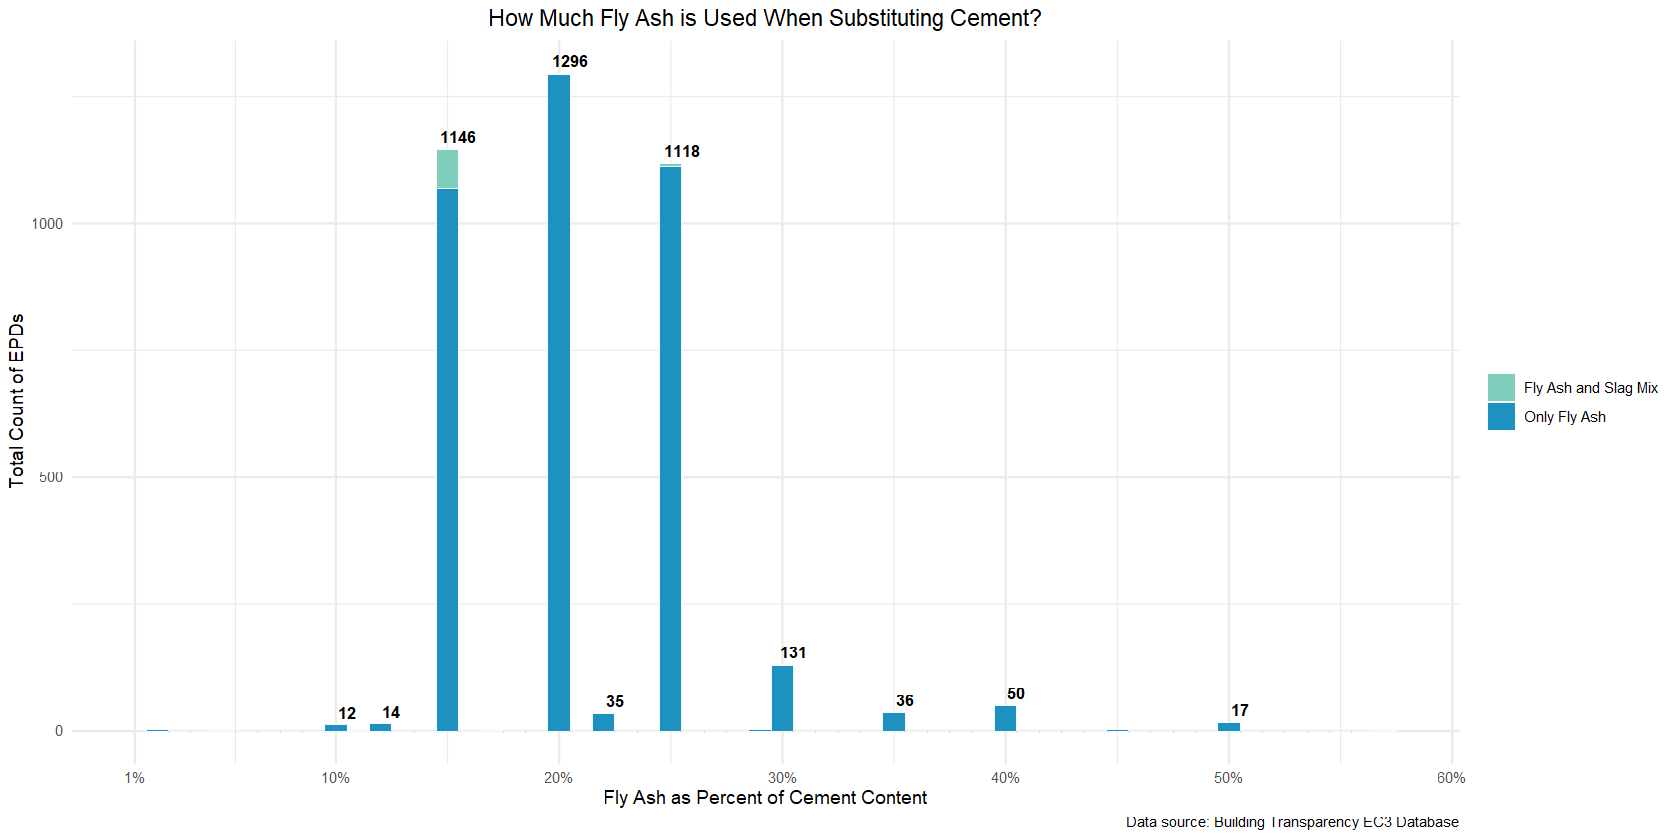

In [110]:
# VISUALIZATION 1: Distribution or Composition

# Set figure size for Jupyter display
options(repr.plot.width = 14, repr.plot.height = 7)

# Classify mixes by slag presence
fly_ash_plot_data <- fly_ash_data %>%
  mutate(mix_type = factor(
    if_else(!is.na(`cementitious.ggbs`) & `cementitious.ggbs` > 0,
            "Fly Ash and Slag Mix",
            "Only Fly Ash"),
    levels = c("Fly Ash and Slag Mix", "Only Fly Ash")
  ))

# Pre-compute bin totals; label bars with count > 10
label_data <- fly_ash_plot_data %>%
  mutate(bin_center = (floor(`cementitious.fly_ash` / 0.01 + 1e-9) * 0.01) + 0.005) %>%
  count(bin_center, name = "total") %>%
  filter(total > 10)

viz1 <- ggplot(fly_ash_plot_data, aes(x = `cementitious.fly_ash`, fill = mix_type)) +
  geom_histogram(binwidth = 0.01, color = "white", linewidth = 0.2) +
  geom_text(
    data = label_data,
    aes(x = bin_center, y = total, label = total),
    inherit.aes = FALSE,
    vjust = -0.5,
    size = 3.5,
    fontface = "bold"
  ) +
  scale_fill_manual(
    values = c("Only Fly Ash" = "#1d91c0", "Fly Ash and Slag Mix" = "#7fcdbb"),
    name = NULL
  ) +
  scale_x_continuous(
    limits = c(0.01, NA),
    breaks = c(0.01, seq(0.10, 0.60, by = 0.10)),
    labels = percent_format(accuracy = 1)
  ) +
  labs(
    title = "How Much Fly Ash is Used When Substituting Cement?",
    x = "Fly Ash as Percent of Cement Content",
    y = "Total Count of EPDs",
    caption = "Data source: Building Transparency EC3 Database"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

viz1

In [111]:
### use ggsave to save viz1 to the tests folder
ggsave("../tests/M15_viz1.png", viz1, width = 14, height = 7, dpi = 300)

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


## Visualization 2: Fly Ash Percentage vs. Global Warming Potential

This scatterplot explores the relationship between fly ash substitution rate and GWP (kg CO2e per cubic yard) across the EPD dataset. Color encodes compressive strength, allowing the viewer to see how concrete strength interacts with both fly ash content and embodied carbon — highlighting whether higher fly ash rates correlate with lower emissions across different strength classes.

In [112]:
# VISUALIZATION 2: EC3 Baselines from Full EPD Dataset

# Load the full EPD dataset (all concrete mixes, not just fly ash)
epd_data_all <- read_csv("../02_processed_data/epd_data_all.csv")

# Apply the same ±250 psi bucketing used for the fly ash data
ec3_baselines <- epd_data_all %>%
  mutate(
    strength_bucket = case_when(
      Compressive_Strength <= 2750 ~ "<= 2,750 psi",
      Compressive_Strength <= 3250 ~ "3,000 psi",
      Compressive_Strength <= 3750 ~ "3,500 psi",
      Compressive_Strength <= 4250 ~ "4,000 psi",
      Compressive_Strength <= 4750 ~ "4,500 psi",
      Compressive_Strength <= 5250 ~ "5,000 psi",
      Compressive_Strength <= 5750 ~ "5,500 psi",
      Compressive_Strength <= 6250 ~ "6,000 psi",
      TRUE                          ~ ">= 6,250 psi"
    )
  ) %>%
  filter(strength_bucket %in% c("3,000 psi", "4,000 psi", "5,000 psi", "6,000 psi")) %>%
  group_by(strength_bucket) %>%
  summarise(gwp = mean(gwp_val_per_cy, na.rm = TRUE), .groups = "drop") %>%
  mutate(label = paste0(strength_bucket, " EC3 avg")) %>%
  arrange(strength_bucket)

ec3_baselines

Rows: 69305 Columns: 24
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (11): name, gwp_per_category_declared_unit, standard_deviation, id, ope...
dbl   (7): uncertainty_factor, plant_or_group.longitude, plant_or_group.lati...
lgl   (1): lightweight
dttm  (5): created_on, updated_on, plant_or_group.created_on, plant_or_group...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


strength_bucket,gwp,label
<chr>,<dbl>,<chr>
"3,000 psi",229.8330,"3,000 psi EC3 avg"
"4,000 psi",259.9470,"4,000 psi EC3 avg"
"5,000 psi",285.0444,"5,000 psi EC3 avg"
"6,000 psi",300.1808,"6,000 psi EC3 avg"


In [113]:
# VISUALIZATION 2: Data Preparation

# Define strength bucket levels and colors
strength_levels <- c("<= 2,750 psi", "3,000 psi", "3,500 psi", "4,000 psi", "4,500 psi",
                     "5,000 psi", "5,500 psi", "6,000 psi", ">= 6,250 psi")

strength_colors <- c(
  "<= 2,750 psi" = "#ffffd9",
  "3,000 psi"    = "#edf8b1",
  "3,500 psi"    = "#c7e9b4",
  "4,000 psi"    = "#7fcdbb",
  "4,500 psi"    = "#41b6c4",
  "5,000 psi"    = "#1d91c0",
  "5,500 psi"    = "#225ea8",
  "6,000 psi"    = "#253494",
  ">= 6,250 psi" = "#081d58"
)

# Classify strength into buckets (±250 psi of named value, except first/last)
fly_ash_viz2 <- fly_ash_data %>%
  mutate(
    strength_bucket = factor(
      case_when(
        Compressive_Strength <= 2750 ~ "<= 2,750 psi",
        Compressive_Strength <= 3250 ~ "3,000 psi",
        Compressive_Strength <= 3750 ~ "3,500 psi",
        Compressive_Strength <= 4250 ~ "4,000 psi",
        Compressive_Strength <= 4750 ~ "4,500 psi",
        Compressive_Strength <= 5250 ~ "5,000 psi",
        Compressive_Strength <= 5750 ~ "5,500 psi",
        Compressive_Strength <= 6250 ~ "6,000 psi",
        TRUE                          ~ ">= 6,250 psi"
      ),
      levels = strength_levels
    )
  )

# Find the highest GWP point in the 25% fly ash bucket for annotation
tag_point <- fly_ash_viz2 %>%
  filter(abs(`cementitious.fly_ash` - 0.25) < 0.001) %>%
  slice_max(gwp_val_per_cy, n = 1)

# Average GWP for fly ash EPDs by matching strength bucket
bucket_averages <- fly_ash_viz2 %>%
  filter(strength_bucket %in% c("3,000 psi", "4,000 psi", "5,000 psi", "6,000 psi")) %>%
  group_by(strength_bucket) %>%
  summarise(avg_gwp = mean(gwp_val_per_cy, na.rm = TRUE), .groups = "drop") %>%
  mutate(
    label = recode(as.character(strength_bucket),
      "3,000 psi" = "3,000 psi average w/ fly ash",
      "4,000 psi" = "4,000 psi average w/ fly ash",
      "5,000 psi" = "5,000 psi average w/ fly ash",
      "6,000 psi" = "6,000 psi average w/ fly ash"
    ),
    color = recode(as.character(strength_bucket),
      "3,000 psi" = "#c7e9b4",
      "4,000 psi" = "#7fcdbb",
      "5,000 psi" = "#1d91c0",
      "6,000 psi" = "#253494"
    )
  )

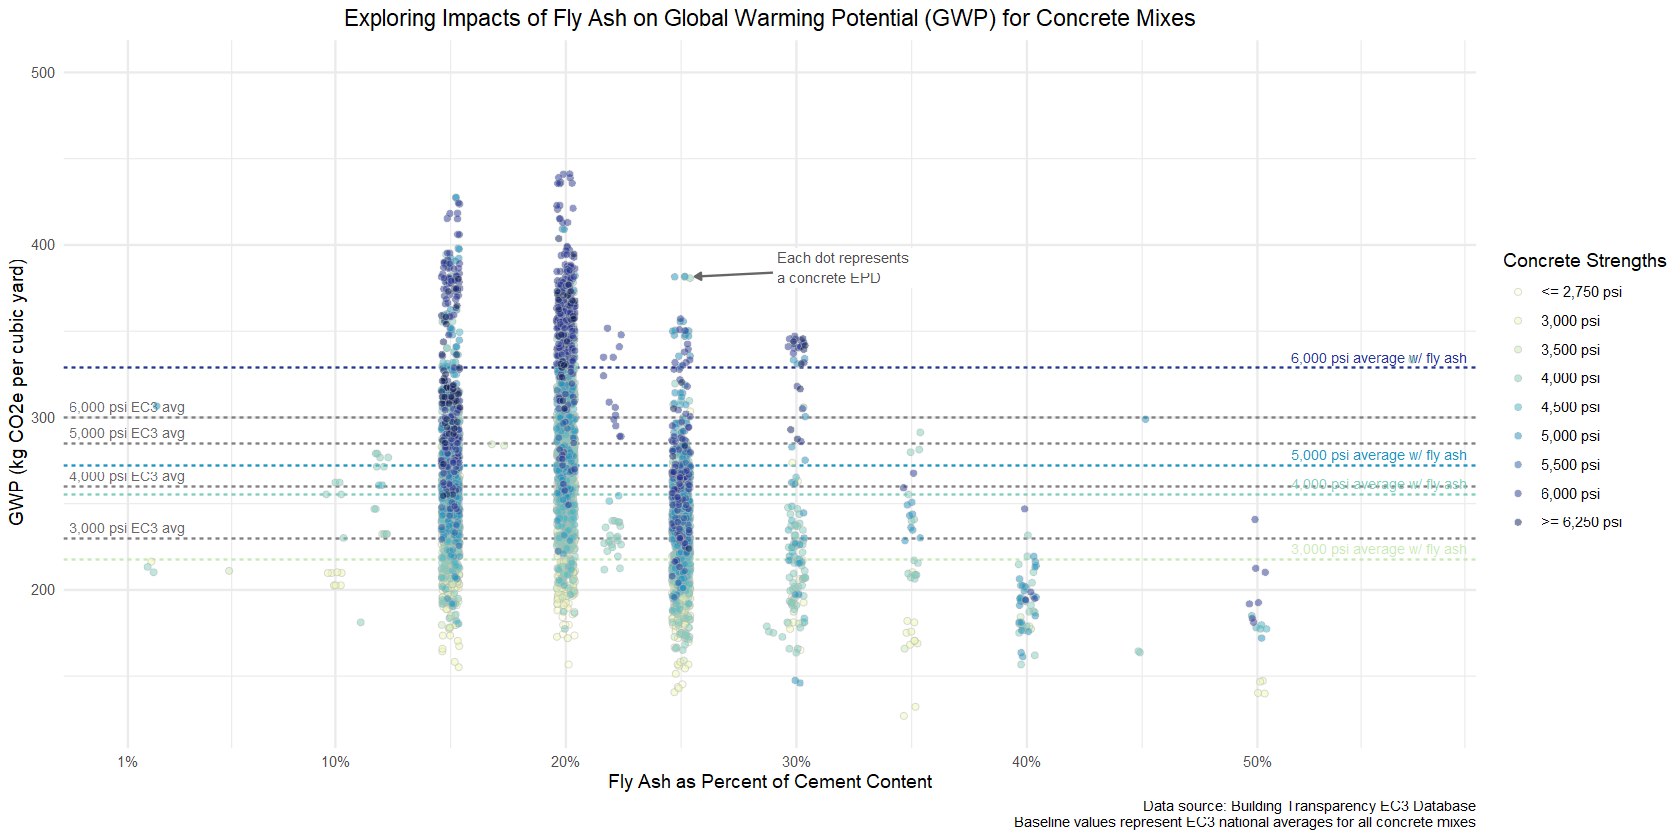

In [114]:
# VISUALIZATION 2: Plot

options(repr.plot.width = 14, repr.plot.height = 7)

viz2 <- ggplot(fly_ash_viz2, aes(x = `cementitious.fly_ash`, y = gwp_val_per_cy)) +
  # EC3 baseline reference lines (grey dashed, labels on left)
  geom_hline(
    data      = ec3_baselines,
    aes(yintercept = gwp),
    linetype  = "dashed",
    color     = "grey50",
    linewidth = 0.5
  ) +
  annotate(
    "text",
    x     = -Inf,
    y     = ec3_baselines$gwp,
    label = ec3_baselines$label,
    hjust = -0.05,
    vjust = -0.5,
    size  = 2.8,
    color = "grey40"
  ) +
  # EPD data average lines by strength bucket (colored to match bucket, labels on right)
  geom_hline(
    data      = bucket_averages,
    aes(yintercept = avg_gwp, color = color),
    linetype  = "dashed",
    linewidth = 0.5
  ) +
  geom_text(
    data        = bucket_averages,
    aes(x = Inf, y = avg_gwp, label = label, color = color),
    hjust       = 1.05,
    vjust       = -0.5,
    size        = 2.8,
    inherit.aes = FALSE
  ) +
  scale_color_identity() +
  geom_jitter(
    aes(fill = strength_bucket),
    shape = 21,
    color = "grey70",
    stroke = 0.3,
    width = 0.004,
    alpha = 0.5,
    size = 1.5
  ) +
  geom_curve(
    data = tag_point,
    aes(
      x    = `cementitious.fly_ash` + 0.08,
      y    = gwp_val_per_cy + 5,
      xend = `cementitious.fly_ash` + 0.006,
      yend = gwp_val_per_cy
    ),
    inherit.aes = FALSE,
    arrow     = arrow(length = unit(0.15, "cm"), type = "closed"),
    color     = "grey40",
    curvature = 0.0,
  ) +
  geom_label(
    data = tag_point,
    aes(
      x     = `cementitious.fly_ash` + 0.04,
      y     = gwp_val_per_cy + 5,
      label = "Each dot represents\na concrete EPD"
    ),
    inherit.aes = FALSE,
    hjust      = 0,
    size       = 3,
    fill       = "white",
    color      = "grey30",
    label.size = 0
  ) +
  scale_fill_manual(
    values = strength_colors,
    name = "Concrete Strengths"
  ) +
  scale_x_continuous(
    limits = c(0.01, NA),
    breaks = c(0.01, seq(0.10, 0.60, by = 0.10)),
    labels = percent_format(accuracy = 1)
  ) +
  coord_cartesian(ylim = c(NA, 500)) +
  labs(
    title = "Exploring Impacts of Fly Ash on Global Warming Potential (GWP) for Concrete Mixes",
    x = "Fly Ash as Percent of Cement Content",
    y = "GWP (kg CO2e per cubic yard)",
    caption = "Data source: Building Transparency EC3 Database\nBaseline values represent EC3 national averages for all concrete mixes"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

viz2

In [115]:
### use ggsave to save viz2 to the tests folder
ggsave("../tests/M15_viz2.png", viz2, width = 14, height = 7, dpi = 300)

## Visualization 3: Geographic Distribution of Concrete and Coal Plants

This map plots concrete plants (from fly ash EPDs) alongside active coal plants across the continental US, with coal plant circle size scaled to generation capacity. It reveals spatial patterns in fly ash supply and demand — notably that concrete plants using fly ash cluster heavily on the coasts while coal plants are concentrated more in the interior of the country.

In [116]:
# Load concrete plant locations from the processed EC3 active plants table
# (filtered to continental US in ec3_concrete_plant_list.ipynb)
concrete_plants <- read_csv("../02_processed_data/active_concrete_plants_ec3.csv")

print(concrete_plants)

Rows: 1042 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): plant_name
dbl (3): latitude, longitude, epd_count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 1,042 × 4
   plant_name        latitude longitude epd_count
   <chr>                <dbl>     <dbl>     <dbl>
 1 Newark                40.7     -74.2      1983
 2 Roseland              40.8     -74.3      1974
 3 Bogota                40.9     -74.0      1964
 4 Howell                40.2     -74.2      1908
 5 North Bergen          40.8     -74.0      1893
 6 Broadway              40.7     -74.1      1717
 7 Port of Portland      45.6    -123.       1469
 8 West Nyack            41.1     -74.0      1466
 9 Vernon                34.0    -118.       1133
10 Queens Lane (wet)     37.4    -122.       1062
# ℹ 1,032 more rows


In [117]:
#Add additional mapping libraries here
library(maps)   # Provides map_data() for US state boundaries (required by ggplot2)

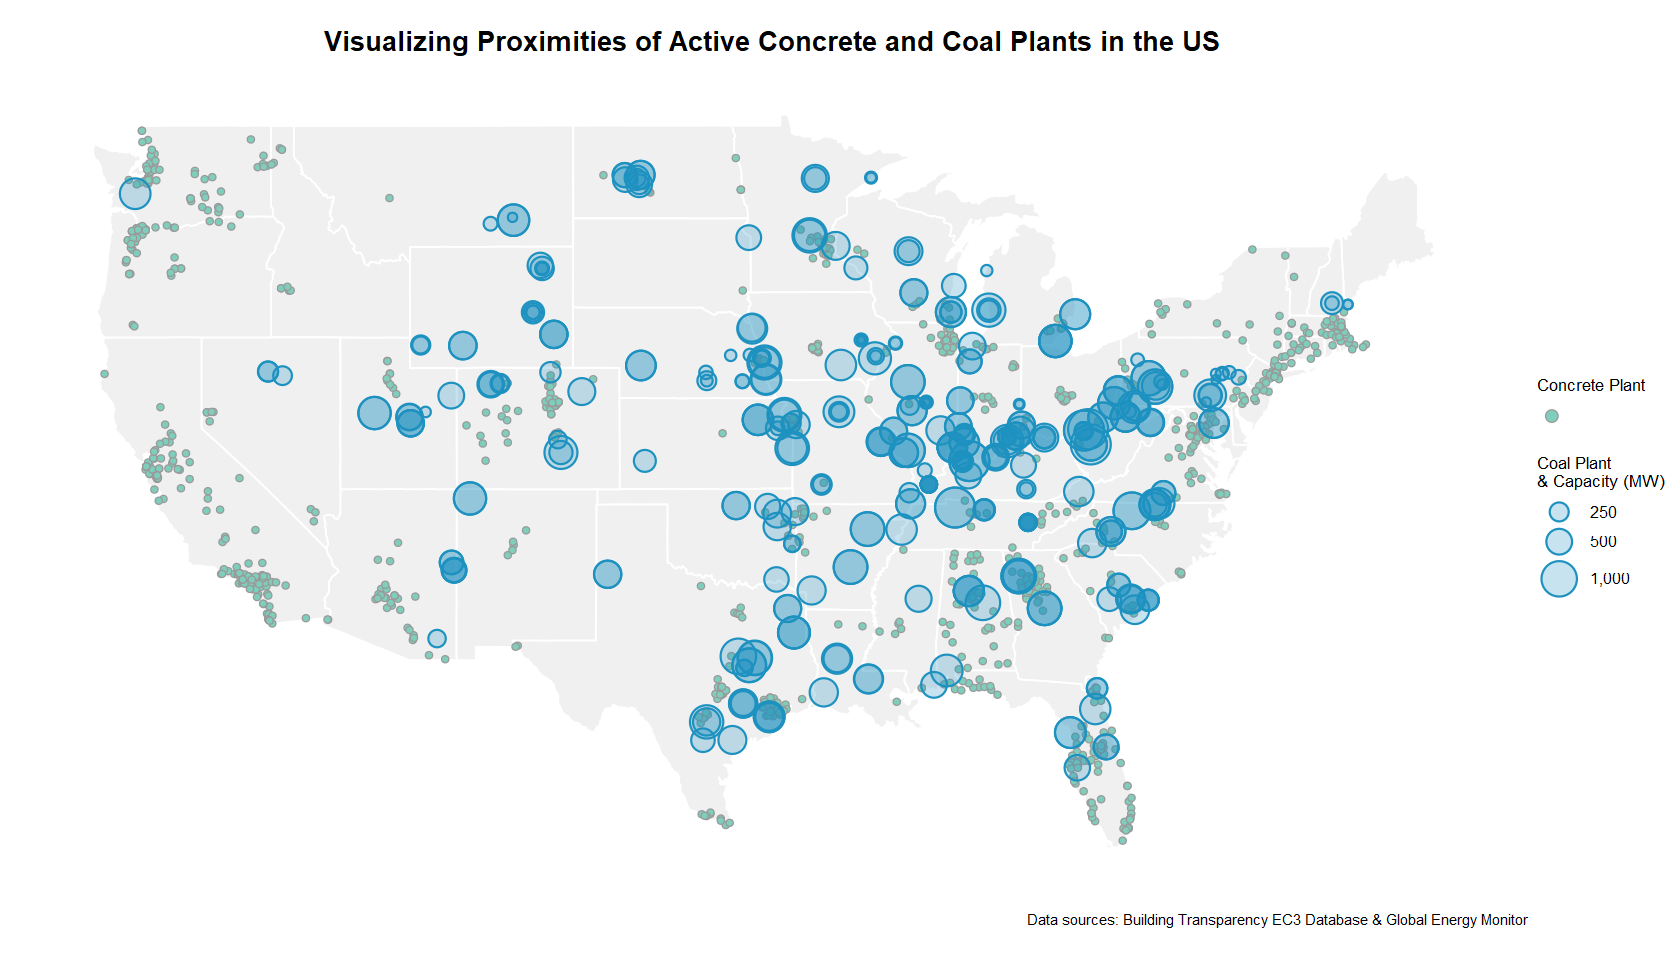

In [118]:
# VISUALIZATION 3: US Coal Plants Map

options(repr.plot.width = 14, repr.plot.height = 8)

# US state boundaries (continental 48 only)
us_states <- map_data("state")

# Filter coal plants to continental US (excludes Alaska, Hawaii, Puerto Rico, etc.)
coal_continental <- coal_plant_data %>%
  filter(
    Latitude  >= 24.5 & Latitude  <= 49.5,
    Longitude >= -125  & Longitude <= -66.5
  )

viz3 <- ggplot() +
  # State polygons
  geom_polygon(
    data      = us_states,
    aes(x = long, y = lat, group = group),
    fill      = "#f0f0f0",
    color     = "white",
    linewidth = 0.4
  ) +
  # Concrete plants: small fixed dots (rendered first so coal plants draw on top)
  geom_point(
    data   = concrete_plants,
    aes(x = longitude, y = latitude,
        fill = "Concrete Plant"),
    shape  = 21,
    color  = "grey60",
    size   = 1.5,
    stroke = 0.4
  ) +
  # Coal plants: circle size scaled to capacity
  geom_point(
    data   = coal_continental,
    aes(x = Longitude, y = Latitude, size = `Capacity (MW)`),
    shape  = 21,
    fill   = scales::alpha("#1d91c0", 0.25),
    color  = "#1d91c0",
    stroke = 0.7
  ) +
  # Fill legend for concrete plants
  scale_fill_manual(
    name   = "Concrete Plant",
    values = c("Concrete Plant" = "#7fcdbb"),
    labels = "",
    guide  = guide_legend(
      override.aes = list(shape = 21, size = 3, color = "grey60", stroke = 0.4)
    )
  ) +
  # Area-proportional size scale with representative legend breaks
  scale_size_area(
    name     = "Coal Plant\n& Capacity (MW)",
    max_size = 10.5,
    breaks   = c(250, 500, 1000),
    labels   = c("250", "500", "1,000")
  ) +
  # Lock aspect ratio and clip to continental US extent
  coord_fixed(ratio = 1.3, xlim = c(-125, -66), ylim = c(24.5, 49.5)) +
  labs(
    title = "Visualizing Proximities of Active Concrete and Coal Plants in the US",
    caption = "Data sources: Building Transparency EC3 Database & Global Energy Monitor"
    ) +
  theme_void() +
  theme(
    plot.title      = element_text(hjust = 0.5, size = 16, face = "bold",
                                   margin = margin(b = 10)),
    legend.position = "right",
    legend.title    = element_text(size = 10),
    legend.text     = element_text(size = 9),
    plot.background = element_rect(fill = "white", color = NA),
    plot.margin     = margin(10, 10, 10, 10),
    legend.spacing.y = unit(15, "pt")
  )

viz3

In [119]:
### use ggsave to save viz3 to the tests folder
ggsave("../tests/M15_viz3.png", viz3, width = 14, height = 8, dpi = 300)